[ 155  355  555  754  953 1153 1352 1552 1751 1951 2150 2350 2549 2749
 2948 3148 3347 3547 3746 3946 4145 4345]
Detected pitch: 221.61 Hz


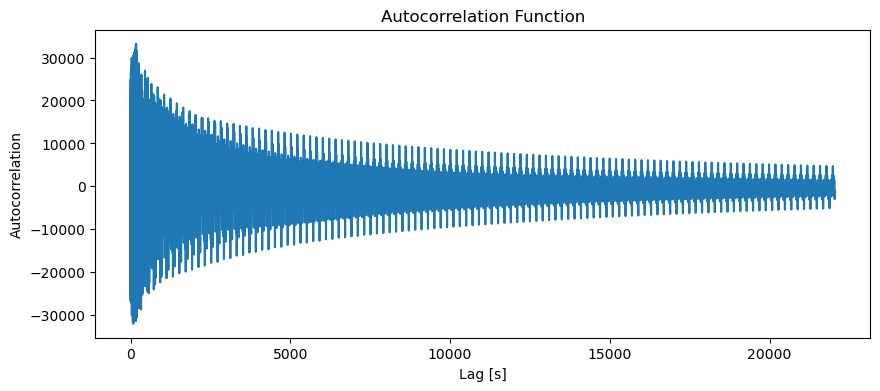

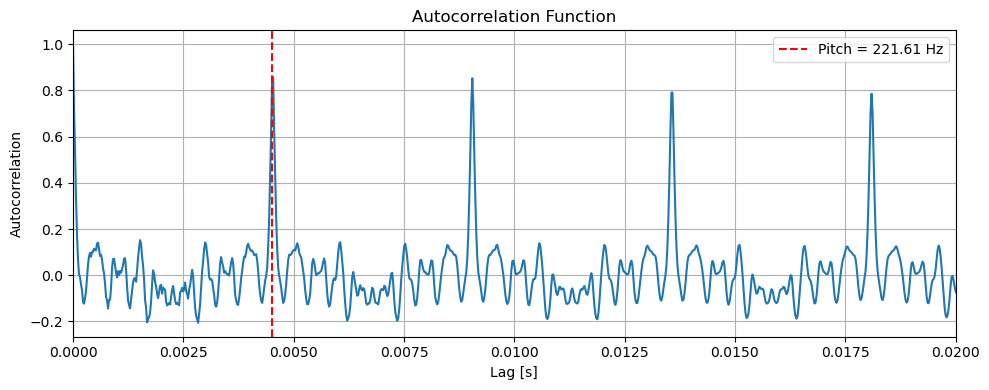

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import find_peaks

# -----------------------------
# Load WAV file
# -----------------------------
fs, signal = wavfile.read("plucked_string_A3.wav")

# Convert to float and mono if needed
signal = signal.astype(np.float32)
if len(signal.shape) > 1:
    signal = signal[:, 0]

# Remove DC
signal = signal - np.mean(signal)

# Optional: take only first 0.5 s (more stable pitch detection)
signal = signal[:int(0.5 * fs)]

# -----------------------------
# Autocorrelation
# -----------------------------
autocorr = np.correlate(signal, signal, mode='full')
autocorr = autocorr[len(autocorr)//2:]  # keep positive lags only

# Normalize
autocorr = autocorr / np.max(autocorr)

# -----------------------------
# Peak detection
# -----------------------------
# Ignore very small lags (below 50 Hz equivalent)
min_freq = 50
min_lag = int(fs / 1000)   # ignore near-zero region


# Only look at lags after min_lag
search_region = autocorr[min_lag:]

peaks, properties = find_peaks(search_region, height=0.5)

print(peaks)
if len(peaks) == 0:
    print("No pitch detected")
else:
    peak_lag = peaks[0] + min_lag
    f0 = fs / peak_lag
    print(f"Detected pitch: {f0:.2f} Hz")

# -----------------------------
# Plot
# -----------------------------
lags = np.arange(len(autocorr)) / fs

plt.figure(figsize=(10,4))
plt.plot(signal)
plt.xlabel("Lag [s]")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Function")


plt.figure(figsize=(10,4))
plt.plot(lags, autocorr)
plt.xlabel("Lag [s]")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Function")

if len(peaks) > 0:
    plt.axvline(peak_lag/fs, color='r', linestyle='--',
                label=f'Pitch = {f0:.2f} Hz')
    plt.legend()

plt.xlim(0, 0.02)
plt.grid()
plt.tight_layout()
plt.show()